# Notebook 2 - Graph Analytics: The F1 Teammate Network

**Goal:** Build a network graph to analyze the historical relationships between Formula 1 drivers using PySpark and GraphFrames.

**Vertices (Nodes):** Drivers.  
**Edges (Relationships):** Two drivers are connected if they raced for the same Constructor in the same Year.

This notebook explores the graph using PageRank, Label Propagation (Community Detection), and Breadth-First Search (BFS).

## 1. Environment Installation (Run Once & Restart)
**IMPORTANT INSTRUCTIONS:** Run this cell *first*. When it finishes, Google Colab will prompt you to **Restart Session**. Click Restart. Once the session has restarted, do NOT run this cell again. Move straight to step 2.

In [1]:
!pip uninstall -y pyspark
!pip install --no-cache-dir pyspark==3.5.1 graphframes

Found existing installation: pyspark 4.0.2
Uninstalling pyspark-4.0.2:
  Successfully uninstalled pyspark-4.0.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.0/317.0 MB 198.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 314.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 301.2 MB/s eta 0:00:00
  Created wheel for pyspark: filename=pyspark-3.5.1-py2.py3-none-any.whl size=317488493 sha256=0e794b5c38d15cd862e106f230fed7e2ff1834b0a3bca5db62b45e38ca6f5da0
  Stored in directory: /tmp/pip-ephem-wheel-cache-n0jd9h1f/wheels/b1/91/5f/283b53010a8016a4ff1c4a1edd99bbe73afacb099645b5471b
Successfully built pyspark
  Attempting uninstall: py4j
    Found existing installation: py4j 0.10.9.9
    Uninstalling py4j-0.10.9.9:
      Successfully uninstalled py4j-0.10.9.9
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of

## 2. Initialization & Data Loading (Run AFTER Restart)
This cell starts Spark 3.5.1 with the GraphFrames package, mounts Google Drive, and loads the clean analytical Gold tables generated by the data engineering pipeline.

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Start Spark Session with the correct GraphFrames package
spark = (
    SparkSession.builder
    .appName("F1 Notebook 2 - Graph Analytics")
    .config("spark.jars.packages", "graphframes:graphframes:0.8.3-spark3.5-s_2.12")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")

# Define paths and load tables
DATASET_PATH = "/content/drive/MyDrive/f1_dataset"
GOLD_PATH = f"{DATASET_PATH}/lakehouse/gold"

fact_race_result = spark.read.parquet(f"{GOLD_PATH}/fact_race_result")
dim_driver = spark.read.parquet(f"{GOLD_PATH}/dim_driver")
dim_constructor = spark.read.parquet(f"{GOLD_PATH}/dim_constructor")

print("Spark 3.5 initialized and Gold tables loaded successfully!")

Mounted at /content/drive
Spark 3.5 initialized and Gold tables loaded successfully!


## 3. Building the GraphFrame
GraphFrames requires two specific DataFrames: one for vertices (must contain an `id` column) and one for edges (must contain `src` and `dst` columns).

In [3]:
from graphframes import GraphFrame

# 1. Create Vertices
vertices = dim_driver.select(
    F.col("driverId").alias("id"),
    "driver_name",
    "nationality"
).distinct()

# 2. Create Edges
# We self-join the fact_race_result table to find drivers who raced for the same team in the same year.
edges_raw = (
    fact_race_result.alias("f1")
    .join(
        fact_race_result.alias("f2"),
        (F.col("f1.constructorId") == F.col("f2.constructorId")) &
        (F.col("f1.year") == F.col("f2.year")) &
        (F.col("f1.driverId") != F.col("f2.driverId")) # Exclude self-matches
    )
    .select(
        F.col("f1.driverId").alias("src"),
        F.col("f2.driverId").alias("dst"),
        F.col("f1.year").alias("year"),
        F.col("f1.constructorId").alias("constructorId")
    )
    .distinct()
)

# Aggregate the years they were teammates to create a "relationship weight"
edges = (
    edges_raw.groupBy("src", "dst", "constructorId")
    .agg(F.count("year").alias("years_as_teammates"))
)

# 3. Initialize the GraphFrame
f1_graph = GraphFrame(vertices, edges)

print(f"Total Drivers (Vertices): {f1_graph.vertices.count()}")
print(f"Total Teammate Relationships (Edges): {f1_graph.edges.count()}")

Total Drivers (Vertices): 861
Total Teammate Relationships (Edges): 16042


## 4. PageRank: Identifying Central Drivers
PageRank measures node importance based on the quantity and quality of links to it. A driver gets a high PageRank if they had many teammates, and those teammates also had many teammates. This helps us find the "anchor" drivers of F1 history.

In [4]:
# Run PageRank
# We use resetProbability=0.15 and maxIter=10 as standard starting parameters
pagerank_results = f1_graph.pageRank(resetProbability=0.15, maxIter=10)

# Show the top 10 most "central" drivers
(
    pagerank_results.vertices
    .orderBy(F.desc("pagerank"))
    .select("id", "driver_name", "pagerank")
    .show(10, truncate=False)
)

+---+-------------------+------------------+
|id |driver_name        |pagerank          |
+---+-------------------+------------------+
|427|Maurice Trintignant|5.700948409615734 |
|475|Stirling Moss      |5.493255373108041 |
|356|Jack Brabham       |5.005245825922141 |
|501|Harry Schell       |4.546791226378888 |
|456|Roy Salvadori      |4.487356053313713 |
|418|Masten Gregory     |4.395893011655027 |
|347|Jo Bonnier         |4.156731707461079 |
|486|Jack Fairman       |3.5733196672116962|
|197|Jean-Pierre Jarier |3.4933620948684907|
|346|Jo Siffert         |3.4672151622179266|
+---+-------------------+------------------+
only showing top 10 rows



## 5. Label Propagation: Community Detection
Label Propagation detects communities within the network by analyzing dense clusters of connections. We enrich the output by joining back to our dimension tables so we can see the actual names of the drivers representing each community.

In [5]:
# Run Label Propagation (Community Detection)
lpa_results = f1_graph.labelPropagation(maxIter=5)

# Get the raw community sizes
community_sizes = (
    lpa_results.groupBy("label")
    .agg(F.count("id").alias("driver_count"))
)

# Join back to dim_driver to get the name of the driver the community is named after
enriched_communities = (
    community_sizes.join(
        dim_driver.select(
            F.col("driverId").alias("label"),
            F.col("driver_name").alias("community_seed_driver")
        ),
        "label",
        "left"
    )
    .orderBy(F.desc("driver_count"))
)

# Show the management-ready output
enriched_communities.show(10, truncate=False)

+-----+------------+---------------------+
|label|driver_count|community_seed_driver|
+-----+------------+---------------------+
|427  |235         |Maurice Trintignant  |
|559  |96          |Pat Flaherty         |
|110  |87          |Andrea de Cesaris    |
|182  |56          |Niki Lauda           |
|209  |34          |Geoff Lees           |
|346  |24          |Jo Siffert           |
|660  |20          |Johnny Claes         |
|32   |18          |Christian Klien      |
|792  |18          |Alfredo Pián         |
|41   |17          |Ricardo Zonta        |
+-----+------------+---------------------+
only showing top 10 rows



## 6. Breadth-First Search (BFS): Degrees of Separation
BFS explores the graph level by level to find the shortest path between nodes. Here, we calculate the "degrees of separation" between a modern champion (Max Verstappen) and a historical champion (Ayrton Senna) based strictly on chains of teammates.

In [6]:
# Find the shortest path of teammates between Ayrton Senna and Max Verstappen
bfs_path = f1_graph.bfs(
    fromExpr="driver_name = 'Ayrton Senna'",
    toExpr="driver_name = 'Max Verstappen'",
    maxPathLength=10
)

bfs_path.show(truncate=False)

# --- Enriching the BFS Path for Management ---
# 1. Isolate the edges from the BFS path
bfs_edges = bfs_path.select("e0", "e1", "e2", "e3").first()

# 2. Extract the data into a readable format
enriched_path = []
for edge_col in bfs_edges:
    if edge_col is not None:
        src = edge_col['src']
        dst = edge_col['dst']
        constructor_id = edge_col['constructorId']
        years = edge_col['years_as_teammates']

        # Look up the actual team name and driver names from our Gold tables
        team_name = dim_constructor.filter(F.col("constructorId") == constructor_id).select("constructor_name").first()[0]
        src_name = dim_driver.filter(F.col("driverId") == src).select("driver_name").first()[0]
        dst_name = dim_driver.filter(F.col("driverId") == dst).select("driver_name").first()[0]

        enriched_path.append({
            "Driver 1": src_name,
            "Driver 2": dst_name,
            "Team": team_name,
            "Years as Teammates": years
        })

# 3. Display the Management-Ready output
spark.createDataFrame(enriched_path).show(truncate=False)

+------------------------------+---------------+------------------------------+--------------+--------------------------------+-----------------+-----------------------------------+----------------+----------------------------+
|from                          |e0             |v1                            |e1            |v2                              |e2               |v3                                 |e3              |to                          |
+------------------------------+---------------+------------------------------+--------------+--------------------------------+-----------------+-----------------------------------+----------------+----------------------------+
|{102, Ayrton Senna, Brazilian}|{102, 14, 3, 1}|{14, David Coulthard, British}|{14, 24, 9, 1}|{24, Vitantonio Liuzzi, Italian}|{24, 817, 164, 1}|{817, Daniel Ricciardo, Australian}|{817, 830, 9, 3}|{830, Max Verstappen, Dutch}|
+------------------------------+---------------+------------------------------+---------

## 7. Visualization: Network Graph of the Largest Community

**Big Data Context Disclaimer:** To visualize the clusters, we must extract the graph data from Spark's distributed architecture into local memory using `.toPandas()` to leverage the `NetworkX` and `Matplotlib` libraries. **This is not a "big data safe" operation**, as calling `.toPandas()` on a massive dataset would cause an Out-Of-Memory (OOM) error on the driver node.

To mitigate this and simulate a production-safe environment, we are aggressively filtering the distributed PySpark DataFrame first. We isolate *only* the vertices and edges belonging to the single largest community before calling `.toPandas()`. This ensures only a highly compressed, aggregated subset of data is pulled into local memory exclusively for management reporting visuals.

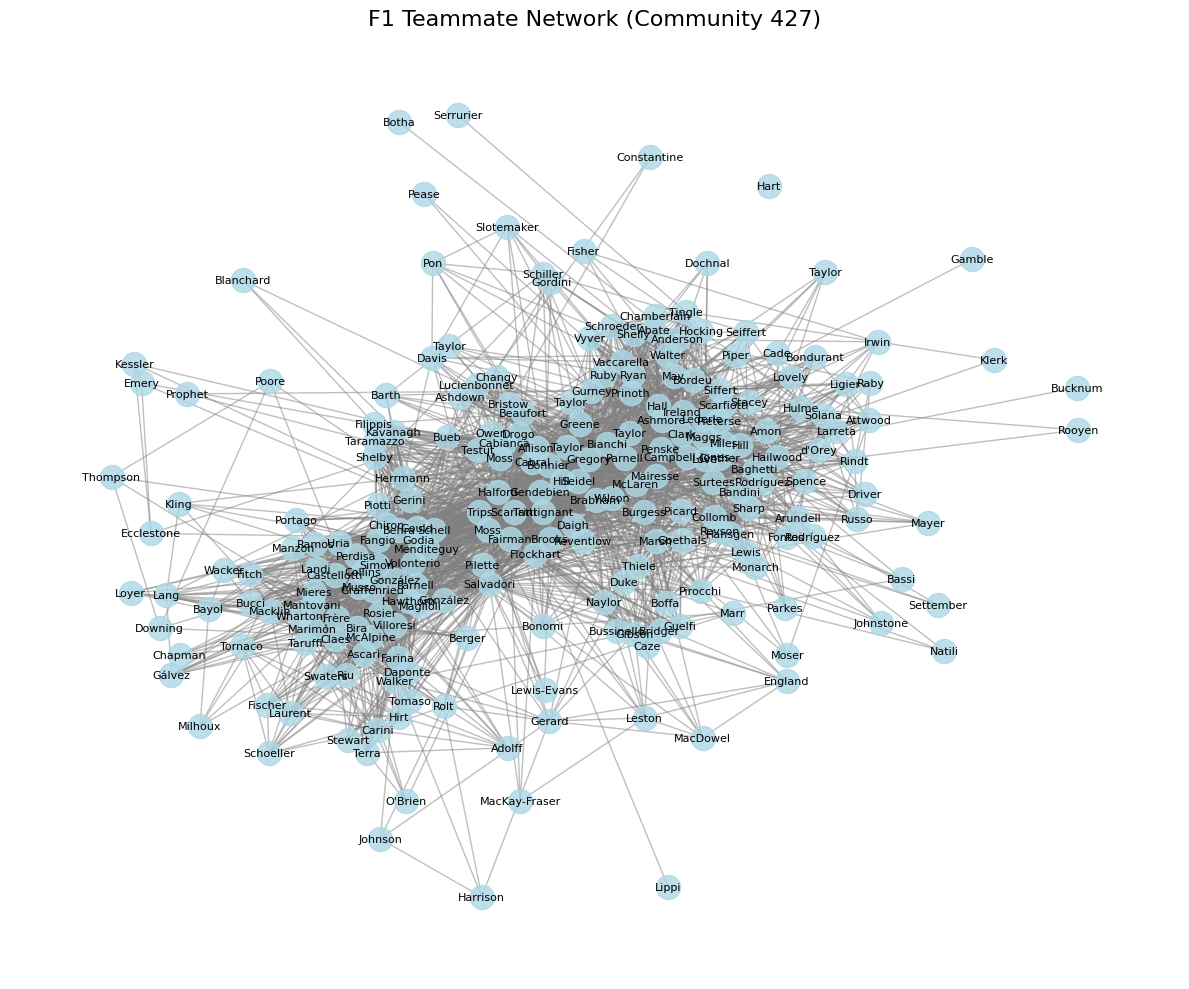

In [7]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Identify the label of the largest community
largest_community_label = (
    lpa_results.groupBy("label")
    .count()
    .orderBy(F.desc("count"))
    .first()["label"]
)

# 2. Filter Spark DataFrames to ONLY include nodes and edges in this community
community_nodes_spark = lpa_results.filter(F.col("label") == largest_community_label)

community_edges_spark = (
    edges.alias("e")
    .join(community_nodes_spark.alias("src_node"), F.col("e.src") == F.col("src_node.id"), "inner")
    .join(community_nodes_spark.alias("dst_node"), F.col("e.dst") == F.col("dst_node.id"), "inner")
    .select("e.src", "e.dst", "e.years_as_teammates")
)

# 3. Pull the highly filtered data into local memory (Pandas)
pdf_nodes = community_nodes_spark.select("id", "driver_name").toPandas()
pdf_edges = community_edges_spark.toPandas()

# 4. Build the NetworkX Graph
G = nx.Graph()

for index, row in pdf_nodes.iterrows():
    # Only use the last name to keep the plot clean
    last_name = row['driver_name'].split(" ")[-1]
    G.add_node(row['id'], label=last_name)

for index, row in pdf_edges.iterrows():
    G.add_edge(row['src'], row['dst'], weight=row['years_as_teammates'])

# 5. Draw the Graph
plt.figure(figsize=(12, 10))
# spring_layout clusters highly connected nodes together visually
pos = nx.spring_layout(G, k=0.5, seed=42)
labels = nx.get_node_attributes(G, 'label')

# Draw nodes, edges, and labels
nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=300, alpha=0.8)
nx.draw_networkx_edges(G, pos, edge_color='gray', alpha=0.5)
nx.draw_networkx_labels(G, pos, labels=labels, font_size=8, font_family="sans-serif")

plt.title(f"F1 Teammate Network (Community {largest_community_label})", fontsize=16)
plt.axis("off")
plt.tight_layout()
plt.show()